# Marketing · quanto da venda a mídia realmente causa?

No caso Vértice, o KR4.1 (POAS) subiu de 1,31 para 1,58 e ainda está em risco frente à meta de 1,80. E há um problema anterior: o POAS usa a receita **atribuída pela plataforma**. Cada plataforma se dá crédito pela mesma venda, e a soma das atribuições passa das vendas reais. Este notebook responde à pergunta que decide o orçamento:

| # | Pergunta | Técnica | KPI |
|---|---|---|---|
| 1 | Qual o ROAS **incremental** de cada canal? | Marketing Mix Modeling (MMM) com adstock e saturação | MK-012 |
| 2 | Dá para confiar no MMM? | Teste geo de desligamento + teste de permutação + análise de poder | MK-011, MK-013 |
| 3 | Como realocar a verba? | Curvas de resposta e otimização com retorno marginal | MK-012 |

> A série de 104 semanas é simulada com **parâmetros verdadeiros conhecidos** (`marketing.VERDADE`). Isso permite algo impossível com dados reais: checar se o método encontra a verdade. Todas as premissas são de camada D; os fatores de inflação da plataforma são ilustrativos.

> **Como ler:** 🧠 explica técnica e código; 🎯 traduz em decisão.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from kpikit import marketing as mk
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
df, beta_real = mk.gerar_serie_mmm()
gasto_sem = sum(df[f'gasto_{c}'].mean() for c in mk.CANAIS)
print(f"{len(df)} semanas · receita média R$ {df.receita.mean()/1e6:,.1f} mi/semana · mídia R$ {gasto_sem/1e6:,.1f} mi/semana")
print(f"Break-even da 1ª compra: ROAS {mk.BREAK_EVEN_ROAS:.1f} (margem de contribuição de {1/mk.BREAK_EVEN_ROAS:.0%})")

104 semanas · receita média R$ 153.9 mi/semana · mídia R$ 6.6 mi/semana
Break-even da 1ª compra: ROAS 4.5 (margem de contribuição de 22%)


🎯 **O número que ninguém coloca no painel.** Com margem de contribuição de 22%, a mídia só se paga **na primeira compra** se o ROAS incremental passar de ~4,5. Abaixo disso, o canal só faz sentido se a recompra (LTV) cobrir a diferença. Por isso ROAS "bom" de plataforma (5 a 9) pode esconder canais que **destroem margem**.

## 1. MMM · separar a venda da base da venda causada pela mídia

🧠 **Por dentro da técnica.** O MMM explica a receita semanal como

$$\text{receita}_t = \underbrace{\text{tendência} + \text{sazonalidade} + \text{eventos}}_{\text{base}} + \sum_c \beta_c \cdot \text{saturação}\big(\text{adstock}(\text{gasto}_c)\big)_t + \varepsilon_t$$

- **Adstock** (`adstock`): parte do efeito de hoje "sobra" para as próximas semanas (θ de 0 a 1). Vídeo e redes sociais costumam ter θ maior que busca.
- **Saturação** (`hill`): cada real a mais rende menos que o anterior, `x / (x + k)`.
- **Estimação:** para cada combinação de θ e k, os coeficientes saem de **mínimos quadrados com limites** (`scipy.optimize.lsq_linear`): controles livres, efeito de mídia ≥ 0 (mídia não destrói venda). A busca em grade testa um canal por vez e repete o ciclo 3 vezes (*coordinate descent*).
- **Validação:** reajustamos só com o passado e prevemos as 12 semanas finais.

R² = 0.998 · MAPE nas 12 semanas finais (fora da amostra) = 0.7%


Text(0.0, 1.0, 'Decomposição da receita: base × contribuição de cada canal')

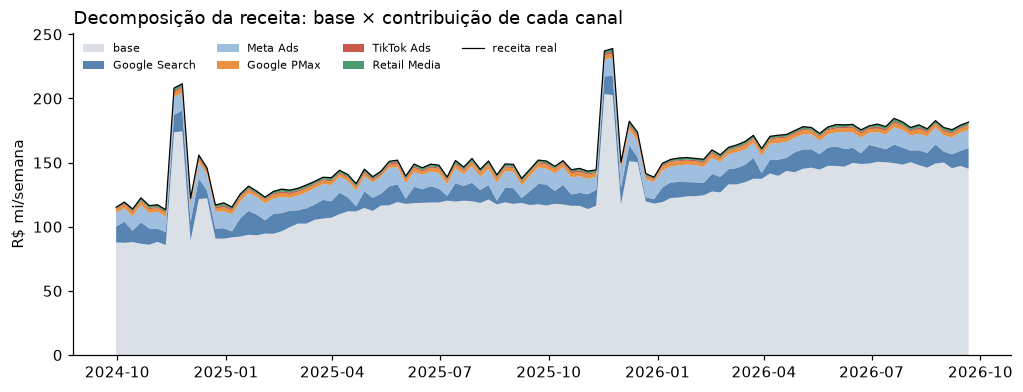

In [2]:
m = mk.ajustar_mmm(df)
print(f"R² = {m.r2_treino:.3f} · MAPE nas 12 semanas finais (fora da amostra) = {m.mape_teste:.1%}")
contrib = mk.contribuicoes(df, m)
fig, ax = plt.subplots(figsize=(11, 3.8))
base = df.receita - contrib.sum(axis=1)
ax.stackplot(df.semana, base / 1e6, *[contrib[c] / 1e6 for c in mk.CANAIS], labels=['base'] + mk.CANAIS, alpha=.85,
             colors=['#d5dbe3', '#3b6ea5', '#8fb3d9', '#e67e22', '#c0392b', '#2e8b57'])
ax.plot(df.semana, df.receita / 1e6, color='black', lw=.8, label='receita real')
ax.set_ylabel('R$ mi/semana'); ax.legend(fontsize=7, ncol=4, frameon=False, loc='upper left')
ax.set_title('Decomposição da receita: base × contribuição de cada canal', loc='left')

In [3]:
sem_calib = mk.comparar_roas(df, m)
sem_calib[['roas_plataforma', 'roas_incremental_mmm', 'roas_incremental_real', 'paga_1a_compra']]

,roas_plataforma,roas_incremental_mmm,roas_incremental_real,paga_1a_compra
canal,,,,
Google Search,9.53,5.49,5.76,True
Meta Ads,6.29,5.83,3.28,True
Google PMax,6.67,2.46,2.04,False
TikTok Ads,5.26,1.59,1.47,False
Retail Media,6.46,3.44,4.87,False


🎯 **Leitura executiva**
- **A plataforma superestima todos os canais**, mas não na mesma proporção. PMax e TikTok reportam ROAS de 5 a 7, com retorno incremental real de 1,5 a 2. Quem aloca verba pelo ROAS da plataforma move dinheiro **para** os canais que menos causam venda.
- **O MMM acerta Search e TikTok, erra PMax em ~20%, superestima Meta em quase 80%** e subestima Retail Media. Pior: pelo MMM sozinho, Meta **se pagaria na primeira compra** (ROAS 5,8 > 4,5); na verdade, não se paga. Não é defeito de código: com 104 semanas e 5 canais, parte dos efeitos é pouco identificável. **Um MMM sozinho não é uma verdade; é uma hipótese a ser testada.**

## 2. Teste geo · medir o efeito diretamente

🧠 **Por dentro da técnica · holdout geográfico.** Sorteamos metade de 30 praças para **desligar Meta** por 6 semanas. As demais seguem normalmente. A comparação usa **diferença-em-diferenças**:

$$\text{lift} = (\bar{y}^{\,tratadas}_{teste} - \bar{y}^{\,tratadas}_{pré}) - (\bar{y}^{\,controle}_{teste} - \bar{y}^{\,controle}_{pré})$$

Comparar cada praça com ela mesma remove diferenças de tamanho; comparar com o controle remove choques comuns (clima, feriado). Venda perdida ÷ verba economizada = **ROAS incremental**.

**Por que permutação e não teste t?** Com 30 praças de tamanhos muito diferentes, a normalidade é duvidosa. O teste de permutação sorteia de novo quem é "tratada" 2.000 vezes e pergunta com que frequência o acaso produz um lift tão grande. É exato e não supõe distribuição.

In [4]:
painel = mk.gerar_teste_geo()
lift = mk.estimar_lift(painel)
perm = mk.teste_permutacao(painel)
print(f"Queda de receita nas praças sem Meta: {lift['lift_pct']:.1%} · verba retirada R$ {-lift['gasto_extra']/1e6:,.1f} mi")
print(f"ROAS incremental de Meta (experimento): {perm['iroas']:.2f}  IC95% [{perm['iroas_ic_inf']:.2f}; {perm['iroas_ic_sup']:.2f}] · p = {perm['p_valor']:.3f}")
print(f"MMM dizia {sem_calib.loc['Meta Ads', 'roas_incremental_mmm']:.2f} · verdade da simulação {sem_calib.loc['Meta Ads', 'roas_incremental_real']:.2f}")

Queda de receita nas praças sem Meta: -20.3% · verba retirada R$ 5.9 mi
ROAS incremental de Meta (experimento): 3.45  IC95% [1.91; 4.90] · p = 0.000
MMM dizia 5.83 · verdade da simulação 3.28


In [5]:
poder = mk.poder_do_teste(simulacoes=80)
poder.style.format('{:.0%}').background_gradient(cmap='Greens', vmin=0.5, vmax=1)

semanas,4,6,8
praças,,,
10,85%,89%,81%
20,100%,100%,100%
30,100%,100%,100%
40,100%,100%,100%


🧠 **Análise de poder: desenhe o teste antes de rodar.** Simulamos o mesmo experimento centenas de vezes para cada combinação de praças × semanas e contamos em quantas o efeito verdadeiro é detectado (p < 5%). Teste sem poder é dinheiro jogado fora: o resultado vem "não significativo" e ninguém sabe se o canal não funciona ou se o teste era pequeno demais.

🎯 **Leitura executiva.** Com 10 praças, o teste deixa de detectar um efeito real em ~1 de cada 7 vezes. Com 20 praças, detecta em todas as simulações, já com **4 semanas**. **O custo do teste é a venda perdida nas praças desligadas**, e a análise de poder mostra que 20 praças × 4 semanas bastam: um terço a menos de praças e de semanas que o desenho inicial (30 × 6). Testar um corte parcial de verba, em vez de desligar, exigiria mais praças ou mais semanas, porque o efeito a detectar é menor.

## 3. MMM calibrado · o experimento ancora o modelo

In [6]:
m_cal = mk.ajustar_mmm(df, calibracao={'Meta Ads': perm['iroas']})
com_calib = mk.comparar_roas(df, m_cal)
pd.DataFrame({'plataforma': sem_calib.roas_plataforma, 'MMM': sem_calib.roas_incremental_mmm,
              'MMM calibrado': com_calib.roas_incremental_mmm, 'verdade': com_calib.roas_incremental_real})

,plataforma,MMM,MMM calibrado,verdade
canal,,,,
Google Search,9.53,5.49,5.85,5.76
Meta Ads,6.29,5.83,3.45,3.28
Google PMax,6.67,2.46,3.17,2.04
TikTok Ads,5.26,1.59,1.94,1.47
Retail Media,6.46,3.44,3.89,4.87


In [7]:
linhas = {}
for nome, modelo in [('MMM sem calibração', m), ('MMM calibrado', m_cal)]:
    o = mk.otimizar_orcamento(df, modelo)
    atual, nova = mk.receita_real_regime(o.gasto_atual, beta_real), mk.receita_real_regime(o.gasto_otimo, beta_real)
    linhas[nome] = {'erro_roas_ponderado': mk.erro_roas(mk.comparar_roas(df, modelo)),
                    'ganho_prometido': o.receita_otima.sum() / o.receita_atual.sum() - 1,
                    'ganho_real': nova / atual - 1, 'receita_real_extra_mi_ano': (nova - atual) * 52 / 1e6}
t = mk.comparar_roas(df, m); o = mk.otimizar_orcamento(df, m)
w = t.roas_plataforma / t.roas_plataforma.mean(); g = (o.gasto_atual * w).clip(o.gasto_atual * .5, o.gasto_atual * 2)
g = g * o.gasto_atual.sum() / g.sum()
linhas['Regra: verba segue ROAS da plataforma'] = {'ganho_real': mk.receita_real_regime(g, beta_real) / mk.receita_real_regime(o.gasto_atual, beta_real) - 1,
    'receita_real_extra_mi_ano': (mk.receita_real_regime(g, beta_real) - mk.receita_real_regime(o.gasto_atual, beta_real)) * 52 / 1e6}
pd.DataFrame(linhas).T

,erro_roas_ponderado,ganho_prometido,ganho_real,receita_real_extra_mi_ano
MMM sem calibração,0.33,0.07,0.06,81.98
MMM calibrado,0.17,0.06,0.07,90.81
Regra: verba segue ROAS da plataforma,NaN,NaN,0.04,48.31


🧠 **Como a calibração funciona aqui.** O β de Meta é **fixado** para reproduzir o ROAS medido no experimento, e os demais canais são reestimados em torno dele. É a forma mais simples de calibração. Ferramentas como Meridian (Google) e Robyn (Meta) fazem o mesmo com mais sofisticação, usando o experimento como *prior* bayesiano ou como penalidade no ajuste.

🎯 **Leitura executiva**
- **A calibração corta o erro do modelo pela metade** e muda a recomendação onde ela mais importa: sem calibração, o modelo **corta 30% de Retail Media**, que na verdade é o 2º canal mais eficiente. Calibrado, ele **aumenta Retail Media em 36%**.
- **O modelo sem calibração promete mais do que entrega.** O calibrado promete menos e entrega mais. Na régua da verdade da simulação, a realocação calibrada rende ~R$ 90 milhões/ano de receita incremental **com o mesmo orçamento**.
- **Alocar pelo ROAS da plataforma** captura só cerca da metade desse ganho.
- **Governança recomendada:** MMM trimestral + **1 teste geo por trimestre** no canal de maior incerteza (maior investimento × maior divergência MMM–plataforma). O KPI MK-013 (erro do MMM contra o experimento) mede se o modelo merece confiança.

,gasto_atual,gasto_otimo,variacao,roas_marginal_otimo
Google Search,"2,132,297.81","3,174,688.53",0.49,2.55
Meta Ads,"2,129,749.82","1,791,065.97",-0.16,2.08
Google PMax,"1,213,731.85","644,507.42",-0.47,2.28
TikTok Ads,"627,914.85","313,963.72",-0.50,1.93
Retail Media,"504,532.32","684,001.01",0.36,2.11


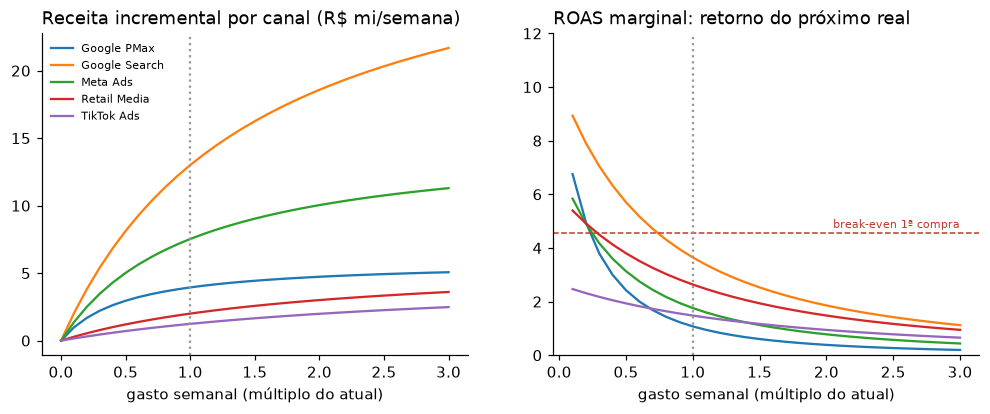

In [8]:
curvas = mk.curvas_resposta(df, m_cal)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for c, g in curvas.groupby('canal'):
    ax[0].plot(g.multiplo_do_atual, g.receita_incremental / 1e6, label=c)
    ax[1].plot(g.multiplo_do_atual, g.roas_marginal, label=c)
ax[1].axhline(mk.BREAK_EVEN_ROAS, color='#c0392b', ls='--', lw=1); ax[1].text(2.05, mk.BREAK_EVEN_ROAS + .2, 'break-even 1ª compra', fontsize=7, color='#c0392b')
for a in ax: a.axvline(1, color='#999', ls=':'); a.set_xlabel('gasto semanal (múltiplo do atual)')
ax[0].set_title('Receita incremental por canal (R$ mi/semana)', loc='left'); ax[1].set_title('ROAS marginal: retorno do próximo real', loc='left')
ax[1].set_ylim(0, 12); ax[0].legend(fontsize=7, frameon=False)
mk.otimizar_orcamento(df, m_cal)[['gasto_atual', 'gasto_otimo', 'variacao', 'roas_marginal_otimo']]

🎯 **A regra de ouro da alocação: iguale o ROAS marginal, não o médio.** Enquanto um canal devolver mais pelo próximo real do que outro, vale mover verba. O ótimo é onde os retornos marginais se igualam, dentro dos guarda-corpos (−50% a +100% do gasto atual, porque o modelo só conhece a faixa de gasto que já observou). Um canal com ROAS médio alto pode ter retorno marginal baixo se já estiver saturado.

**Conexão com a operação:** mais venda incremental na semana errada custa caro no CD. O preço-sombra do caso principal mostrou que 1 pedido a mais na semana da Black Friday custa ~6× a média. **O plano de mídia precisa passar pelo S&OP** (SLA Marketing → Supply em `00-fundamentos/interdependencias.md`).

---
*KPIs: MK-001 (ROAS de plataforma), MK-002 (POAS), MK-003 (MER), MK-011 (ROAS incremental de experimento), MK-012 (ROAS marginal), MK-013 (erro do MMM contra experimento). Material de portfólio com dados simulados e premissas declaradas.*